# Análise de Dados - ENEM 2021

Como métrica de desempenho, adotaremos a média geral das cinco notas (Ciências da Natureza, Ciências Humanas, Linguagens, Matemática e Redação).

O notebook está organizado da seguinte forma:

1. Carregamento e tradução dos códigos segundo o dicionário oficial do INEP
2. Estatísticas descritivas das notas
3. Gráficos exploratórios: tipo de escola, cor/raça, renda, escolaridade da mãe, sexo e acesso a computador e internet
4. Mapa da nota média geral por UF
5. Análise fragmentada: comparações concretas entre grupos socioeconômicos
6. Ranking dos fatores por correlação de Spearman, que responde à pergunta de pesquisa
7. Achados do ano - números-chave calculados automaticamente

As figuras são salvas em `reports/figures/<ano>/` (PNG, 300 dpi), uma subpasta por ano, seguindo o mesmo padrão do notebook de 2020. A síntese dos achados de todos os anos é consolidada em `analise_consolidada_edicoes_enem.ipynb`, que deve ser executado por último, depois de todos os notebooks de análise.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANO = 2021

PROCESSED_PATH = Path('..') / 'data' / 'processed' / f'enem_{ANO}_tratado.parquet'
GEOJSON_PATH = Path('..') / 'data' / 'external' / 'brazil_uf.geojson'
FIGURES_PATH = Path('..') / 'reports' / 'figures' / str(ANO)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTAS = ['Nota_Ciencias_Natureza', 'Nota_Ciencias_Humanas', 'Nota_Linguagens',
         'Nota_Matematica', 'Nota_Redacao']
NOMES_NOTAS = {
    'Nota_Ciencias_Natureza': 'Ciências da Natureza',
    'Nota_Ciencias_Humanas': 'Ciências Humanas',
    'Nota_Linguagens': 'Linguagens e Códigos',
    'Nota_Matematica': 'Matemática',
    'Nota_Redacao': 'Redação',
    'Nota_Media_Geral': 'Média Geral',
}
# Paleta neutra: 5 passos fixos do viridis, um por prova (ordem fixa, nunca ciclada)
PALETA_NOTAS = dict(zip(NOTAS, sns.color_palette('viridis', 5)))
COR_UNICA = '#31688e'  # azul viridis para gráficos de grupo único


def salvar(fig, nome):
    """Salva a figura na subpasta do ano (ex.: figures/2021/fig_01_distribuicao_notas.png)."""
    caminho = FIGURES_PATH / f'{nome}.png'
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    print(f'Figura salva: {caminho}')

## 1. Carregamento e preparação

Os filtros de qualidade - presença nas quatro provas objetivas e remoção de duplicatas pelo número de inscrição - já foram aplicados no notebook de tratamento, de modo que o Parquet contém apenas candidatos válidos. Candidatos com redação zerada foram mantidos: a nota 0 é um resultado legítimo (prova em branco ou anulada) e excluí-los introduziria viés de seleção.

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
# Métrica principal da pesquisa: média simples das 5 notas
df['Nota_Media_Geral'] = df[NOTAS].mean(axis=1)
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head()

Shape: 1,870,734 linhas x 34 colunas


,Numero_Inscricao,Ano,Faixa_Etaria,Sexo,Cor_Raca,Situacao_Conclusao_EM,Ano_Conclusao_EM,Tipo_Escola,Tipo_Ensino,Nome_Municipio_Escola,...,Q2_Esc_Mae,Q3_Ocup_Pai,Q4_Ocup_Mae,Q5_Pessoas_Resid,Q6_Renda_Fam,Q8_Banheiro,Q12_Geladeira,Q24_Computador,Q25_Internet,Nota_Media_Geral
0,210052384164,2021,12,M,1,1,11,1,<NA>,NaN,...,B,B,B,3,B,B,B,A,A,515.500000
1,210052128335,2021,3,M,3,2,0,2,1,Crato,...,B,B,B,6,B,B,B,B,B,667.599976
2,210051353021,2021,2,F,3,2,0,2,1,Redenção,...,E,F,D,4,C,B,B,B,B,570.059998
3,210053417016,2021,8,F,3,2,0,2,<NA>,NaN,...,B,B,B,2,B,B,B,A,B,485.600006
4,210051128744,2021,4,F,3,2,0,2,1,NaN,...,D,D,B,2,B,B,B,A,B,466.940002


### Tradução de códigos para rótulos legíveis

Os códigos foram conferidos no dicionário oficial dos Microdados ENEM 2021, do INEP (`data/raw/microdados_enem_2021/DICIONÁRIO/`).

Um detalhe que merece atenção na Q008 (banheiros): no dicionário oficial, `A` significa **não ter banheiro em casa**; `B` = um, `C` = dois, `D` = três e `E` = quatro ou mais. O mesmo padrão vale para Q012 (geladeiras) e Q024 (computadores).

Diferenças em relação a 2020: o dicionário desta edição inclui o código `6` em cor/raça ("Não dispõe da informação") e não traz o código `4` (Exterior) em tipo de escola.

In [3]:
MAPA_TIPO_ESCOLA = {1: 'Não respondeu', 2: 'Pública', 3: 'Privada'}
MAPA_COR_RACA = {0: 'Não declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda',
                 4: 'Amarela', 5: 'Indígena', 6: 'Não dispõe da informação'}
MAPA_SEXO = {'M': 'Masculino', 'F': 'Feminino'}
MAPA_DEP_ADM = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
MAPA_LOCALIZACAO = {1: 'Urbana', 2: 'Rural'}

# Questionário socioeconômico (dicionário oficial ENEM 2021):
# Q6 (renda): A = nenhuma renda ... Q = acima de R$ 22.000 (ordem crescente natural)
ORDEM_Q6 = list('ABCDEFGHIJKLMNOPQ')
# Q2 (escolaridade da mãe): A = nunca estudou ... G = pós-graduação; H = 'Não sei'
ORDEM_Q2 = list('ABCDEFGH')
# Q8/Q12/Q24 (banheiro/geladeira/computador): A = não tem, B = 1, C = 2, D = 3, E = 4+
MAPA_QTD = {'A': '0', 'B': '1', 'C': '2', 'D': '3', 'E': '4+'}
ORDEM_QTD = ['0', '1', '2', '3', '4+']
MAPA_Q25 = {'A': 'Não', 'B': 'Sim'}

df['Tipo_Escola_Label'] = df['Tipo_Escola'].map(MAPA_TIPO_ESCOLA)
df['Cor_Raca_Label'] = df['Cor_Raca'].map(MAPA_COR_RACA)
df['Sexo_Label'] = df['Sexo'].map(MAPA_SEXO)
df['Dependencia_Adm_Label'] = df['Dependencia_Adm_Escola'].map(MAPA_DEP_ADM)
df['Localizacao_Label'] = df['Localizacao_Escola'].map(MAPA_LOCALIZACAO)

df[['Tipo_Escola_Label', 'Cor_Raca_Label', 'Sexo_Label']].head()

,Tipo_Escola_Label,Cor_Raca_Label,Sexo_Label
0,Não respondeu,Branca,Masculino
1,Pública,Parda,Masculino
2,Pública,Parda,Feminino
3,Pública,Parda,Feminino
4,Pública,Parda,Feminino


## 2. Estatísticas descritivas das 5 notas

In [4]:
colunas_desc = NOTAS + ['Nota_Media_Geral']
tabela_desc = pd.DataFrame({
    'Média': df[colunas_desc].mean(),
    'Mediana': df[colunas_desc].median(),
    'Desvio-padrão': df[colunas_desc].std(),
    'Mínimo': df[colunas_desc].min(),
    'Q1 (25%)': df[colunas_desc].quantile(0.25),
    'Q3 (75%)': df[colunas_desc].quantile(0.75),
    'Máximo': df[colunas_desc].max(),
})
tabela_desc.index = [NOMES_NOTAS[n] for n in tabela_desc.index]
tabela_desc.round(1)

,Média,Mediana,Desvio-padrão,Mínimo,Q1 (25%),Q3 (75%),Máximo
Ciências da Natureza,493.500000,483.000000,81.900002,0.0,431.7,548.0,867.099976
Ciências Humanas,524.700012,526.700012,95.599998,0.0,449.1,594.5,846.900024
Linguagens e Códigos,504.700012,507.799988,79.300003,0.0,448.5,561.6,826.099976
Matemática,534.500000,513.099976,112.099998,0.0,443.1,613.5,953.099976
Redação,623.700012,620.000000,183.100006,0.0,520.0,740.0,1000.000000
Média Geral,536.200012,526.799988,90.300003,0.0,470.7,595.8,862.700012


## 3. Gráficos exploratórios

Figura salva: ..\reports\figures\2021\fig_01_distribuicao_notas.png


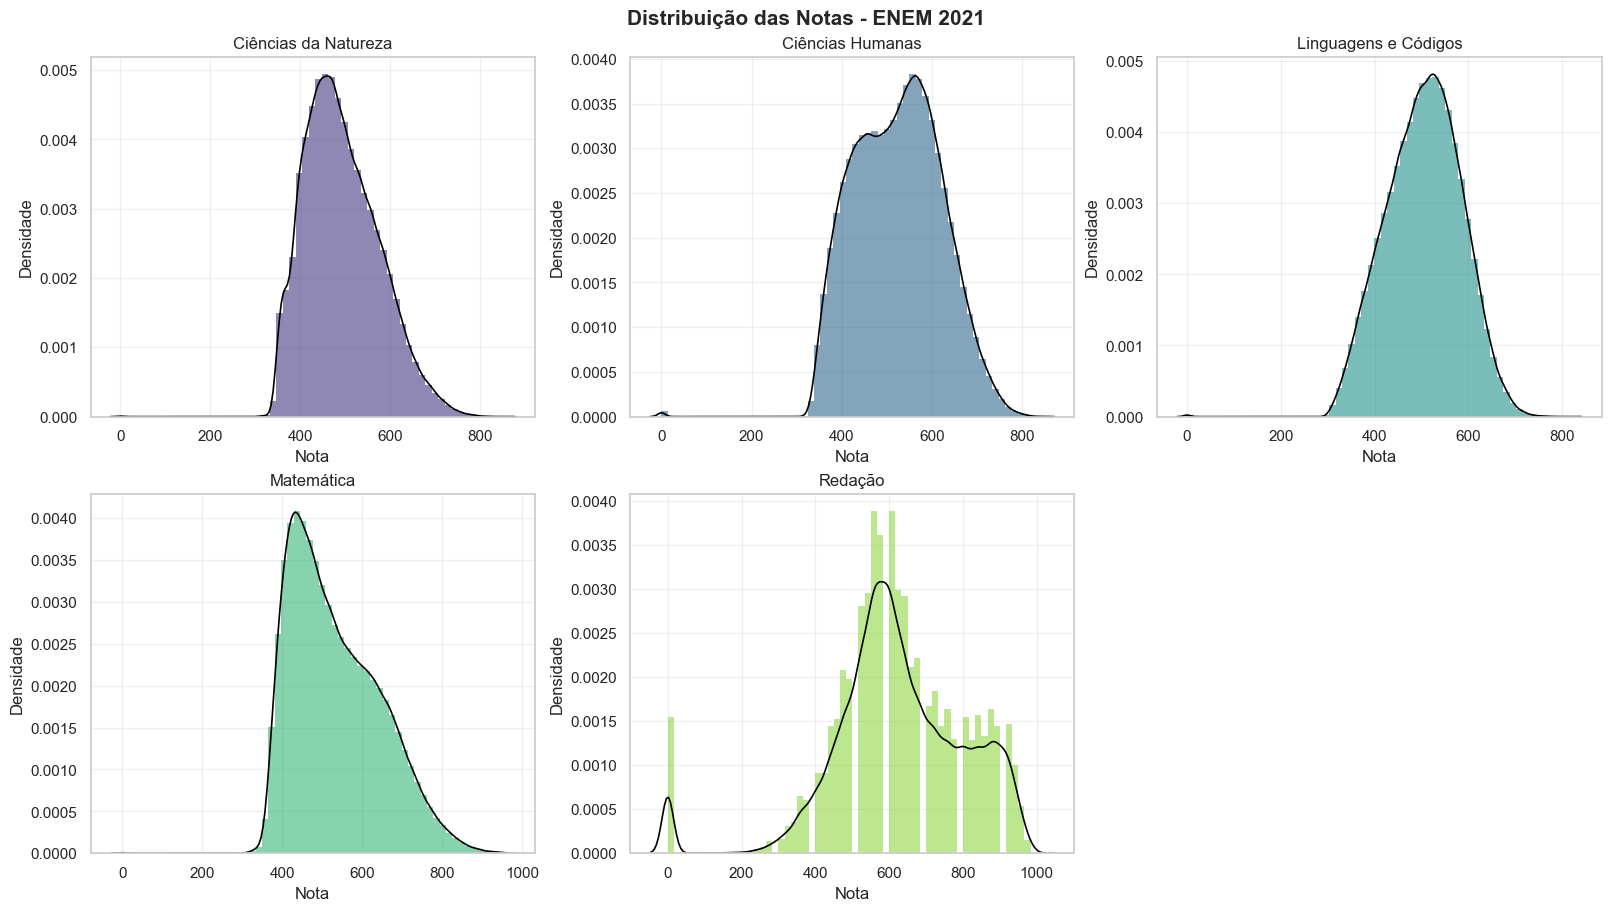

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for ax, nota in zip(axes.flat, NOTAS):
    dados = df[nota].dropna()
    sns.histplot(dados, bins=60, stat='density', color=PALETA_NOTAS[nota],
                 alpha=0.6, edgecolor='none', ax=ax)
    # KDE em amostra de 200 mil pontos (visualmente idêntica e muito mais rápida)
    amostra = dados.sample(min(len(dados), 200_000), random_state=42)
    sns.kdeplot(amostra, color='black', linewidth=1.2, ax=ax)
    ax.set_title(NOMES_NOTAS[nota])
    ax.set_xlabel('Nota')
    ax.set_ylabel('Densidade')
axes.flat[-1].axis('off')
fig.suptitle(f'Distribuição das Notas - ENEM {ANO}', fontsize=15, fontweight='bold')
salvar(fig, 'fig_01_distribuicao_notas')
plt.show()

In [6]:
def boxplots_por_grupo(dados, coluna, ordem, titulo, arquivo, rotacao=0):
    """Grid 2x3 com um boxplot por prova, agrupado pela coluna indicada."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for ax, nota in zip(axes.flat, NOTAS):
        sns.boxplot(data=dados, x=coluna, y=nota, order=ordem,
                    color=COR_UNICA, showfliers=False, ax=ax)
        ax.set_title(NOMES_NOTAS[nota])
        ax.set_xlabel('')
        ax.set_ylabel('Nota')
        if rotacao:
            ax.tick_params(axis='x', rotation=rotacao)
    axes.flat[-1].axis('off')
    fig.suptitle(titulo, fontsize=15, fontweight='bold')
    salvar(fig, arquivo)
    plt.show()

Figura salva: ..\reports\figures\2021\fig_02_notas_por_escola.png


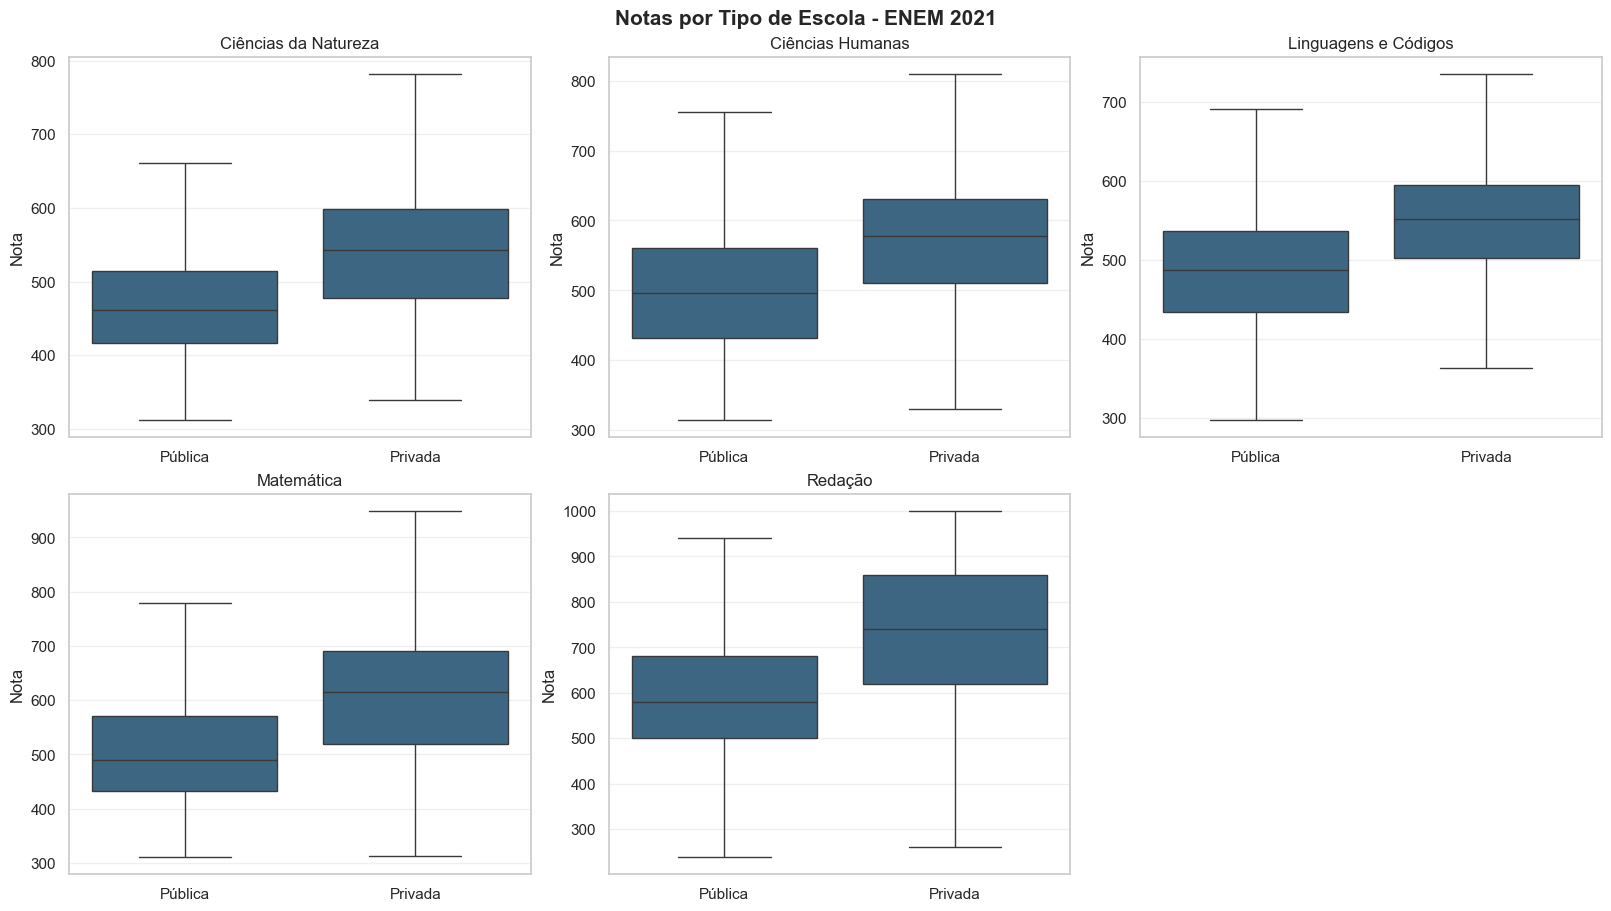

Medianas por Tipo de Escola:


,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Tipo_Escola_Label,,,,,
Privada,542.500000,577.299988,551.799988,615.599976,740.0
Pública,461.399994,496.000000,487.799988,488.899994,580.0


Diferença de Mediana (Privada - Pública):


Ciências da Natureza     81.099998
Ciências Humanas         81.300003
Linguagens e Códigos     64.000000
Matemática              126.699997
Redação                 160.000000
dtype: float32

In [7]:
publica_privada = df[df['Tipo_Escola_Label'].isin(['Pública', 'Privada'])]
boxplots_por_grupo(publica_privada, 'Tipo_Escola_Label', ['Pública', 'Privada'],
                   f'Notas por Tipo de Escola - ENEM {ANO}',
                   'fig_02_notas_por_escola')

medianas_escola = publica_privada.groupby('Tipo_Escola_Label')[NOTAS].median()
medianas_escola.columns = [NOMES_NOTAS[c] for c in medianas_escola.columns]
print('Medianas por Tipo de Escola:')
display(medianas_escola.round(1))
print('Diferença de Mediana (Privada - Pública):')
display((medianas_escola.loc['Privada'] - medianas_escola.loc['Pública']).round(1))

Figura salva: ..\reports\figures\2021\fig_02b_notas_por_dependencia_administrativa.png


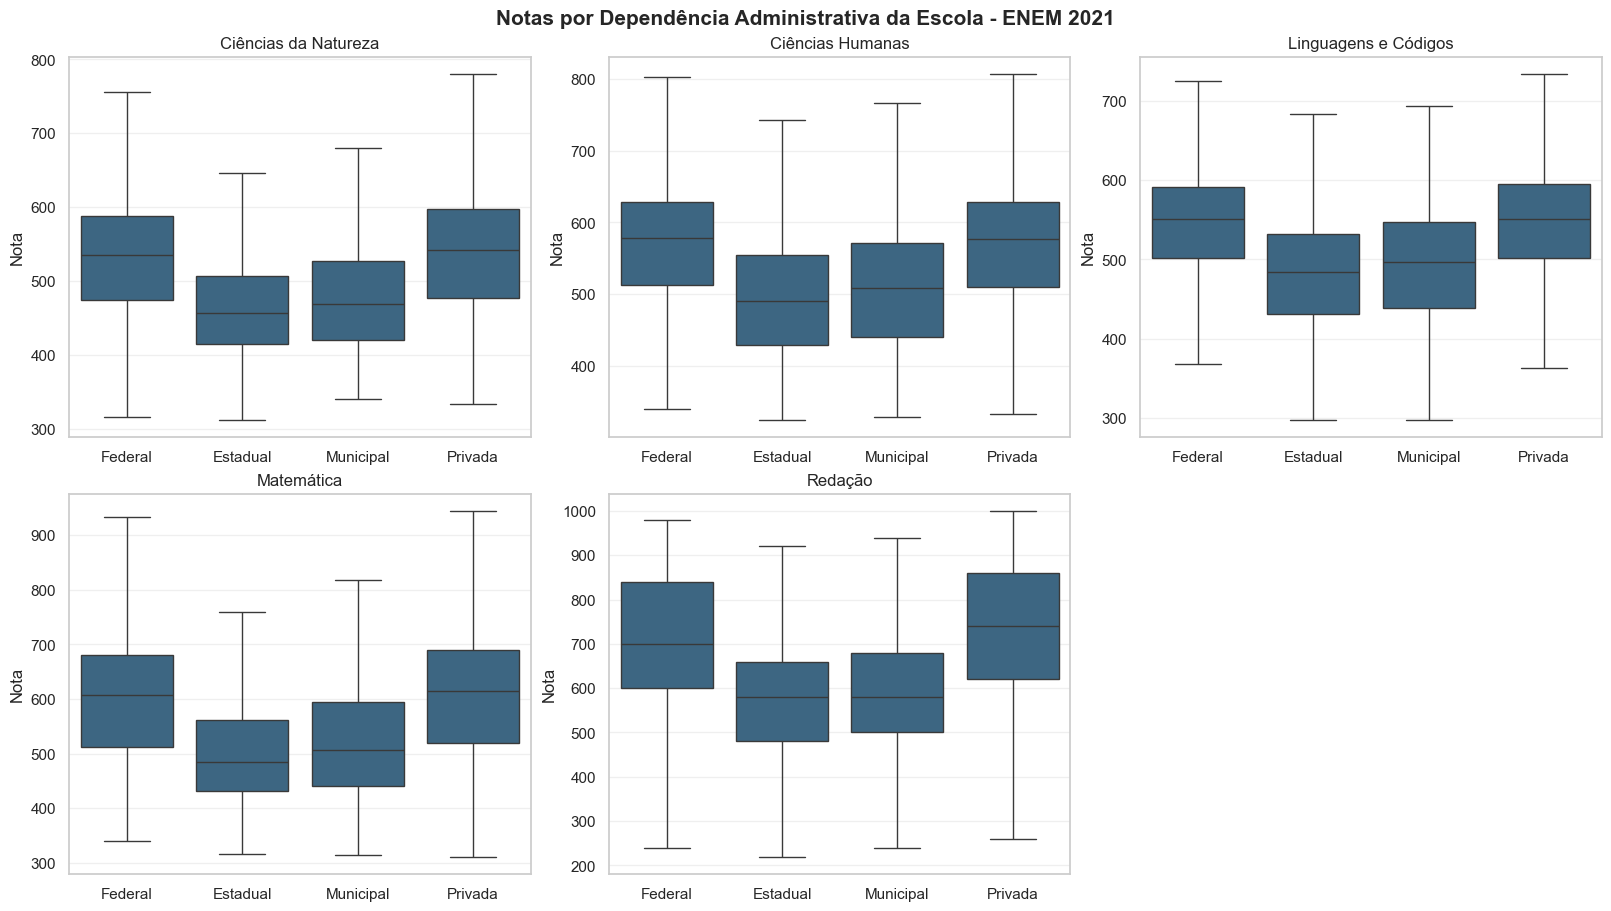

Medianas por Dependência Administrativa:


,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Dependencia_Adm_Label,,,,,
Federal,534.700012,579.000000,550.599976,607.400024,700.0
Estadual,457.100006,489.899994,483.700012,484.399994,580.0
Municipal,468.600006,508.899994,496.799988,506.799988,580.0
Privada,541.900024,576.700012,551.299988,614.099976,740.0


Diferença de Mediana (Federal - Municipal):


Ciências da Natureza     66.099998
Ciências Humanas         70.099998
Linguagens e Códigos     53.799999
Matemática              100.599998
Redação                 120.000000
dtype: float32

In [8]:
ordem_dep_adm = ['Federal', 'Estadual', 'Municipal', 'Privada']
boxplots_por_grupo(df.dropna(subset=['Dependencia_Adm_Label']), 'Dependencia_Adm_Label',
                   ordem_dep_adm, f'Notas por Dependência Administrativa da Escola - ENEM {ANO}',
                   'fig_02b_notas_por_dependencia_administrativa')

medianas_dep_adm = df.groupby('Dependencia_Adm_Label')[NOTAS].median().reindex(ordem_dep_adm)
medianas_dep_adm.columns = [NOMES_NOTAS[c] for c in medianas_dep_adm.columns]
print('Medianas por Dependência Administrativa:')
display(medianas_dep_adm.round(1))
print('Diferença de Mediana (Federal - Municipal):')
display((medianas_dep_adm.loc['Federal'] - medianas_dep_adm.loc['Municipal']).round(1))

Figura salva: ..\reports\figures\2021\fig_03_notas_por_raca.png


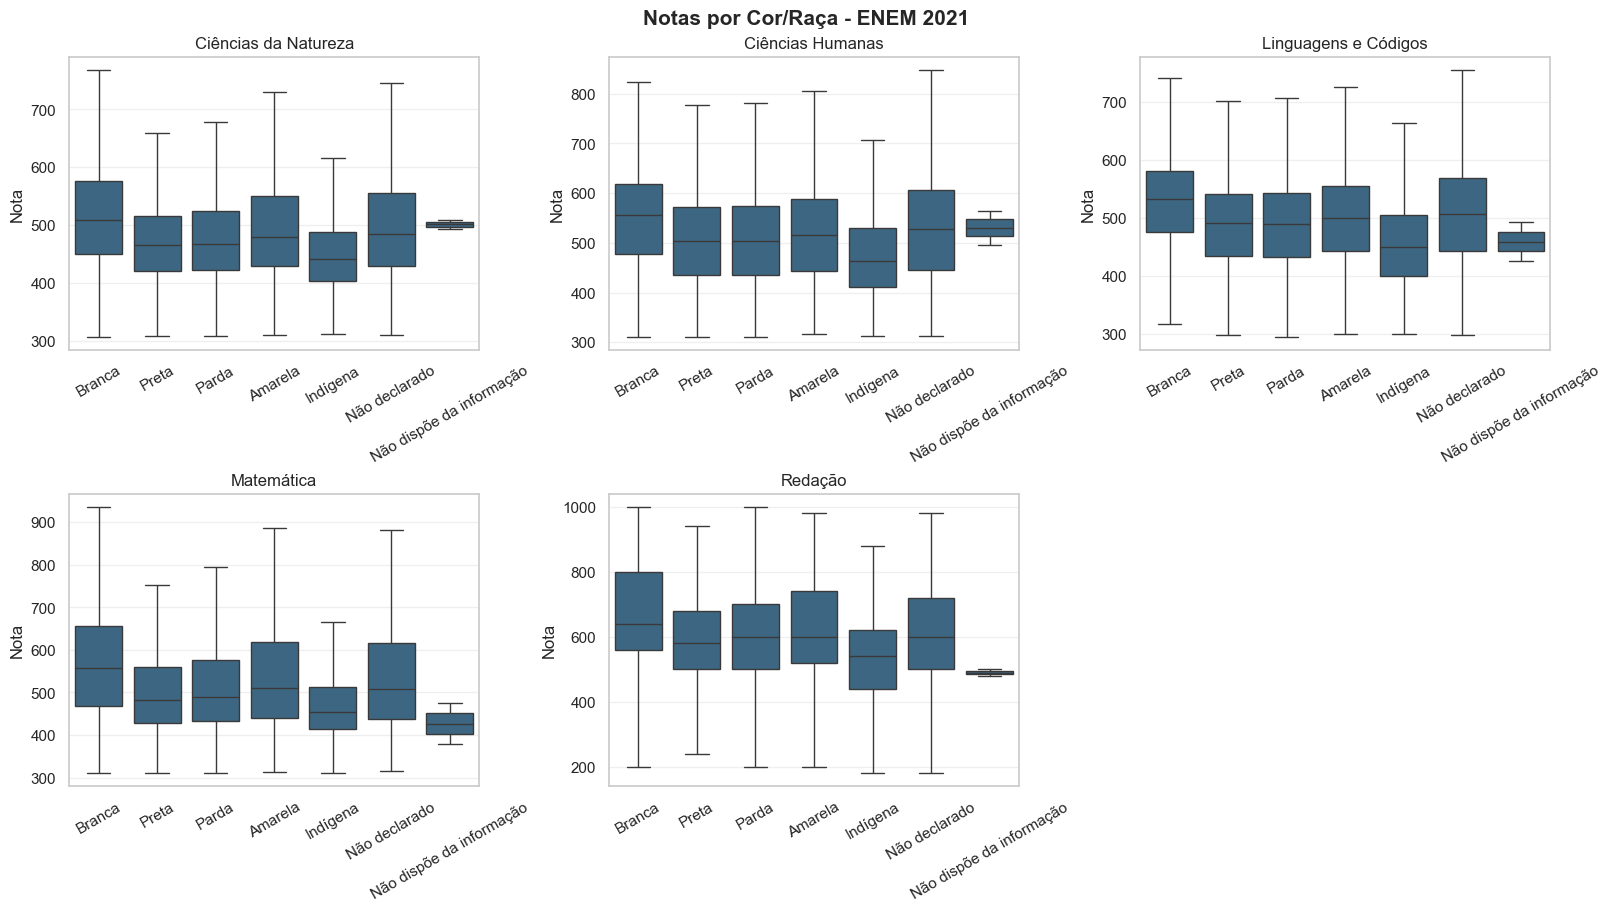

In [9]:
ordem_raca = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarado',
              'Não dispõe da informação']
boxplots_por_grupo(df, 'Cor_Raca_Label', ordem_raca,
                   f'Notas por Cor/Raça - ENEM {ANO}',
                   'fig_03_notas_por_raca', rotacao=30)

Figura salva: ..\reports\figures\2021\fig_04_notas_por_renda.png


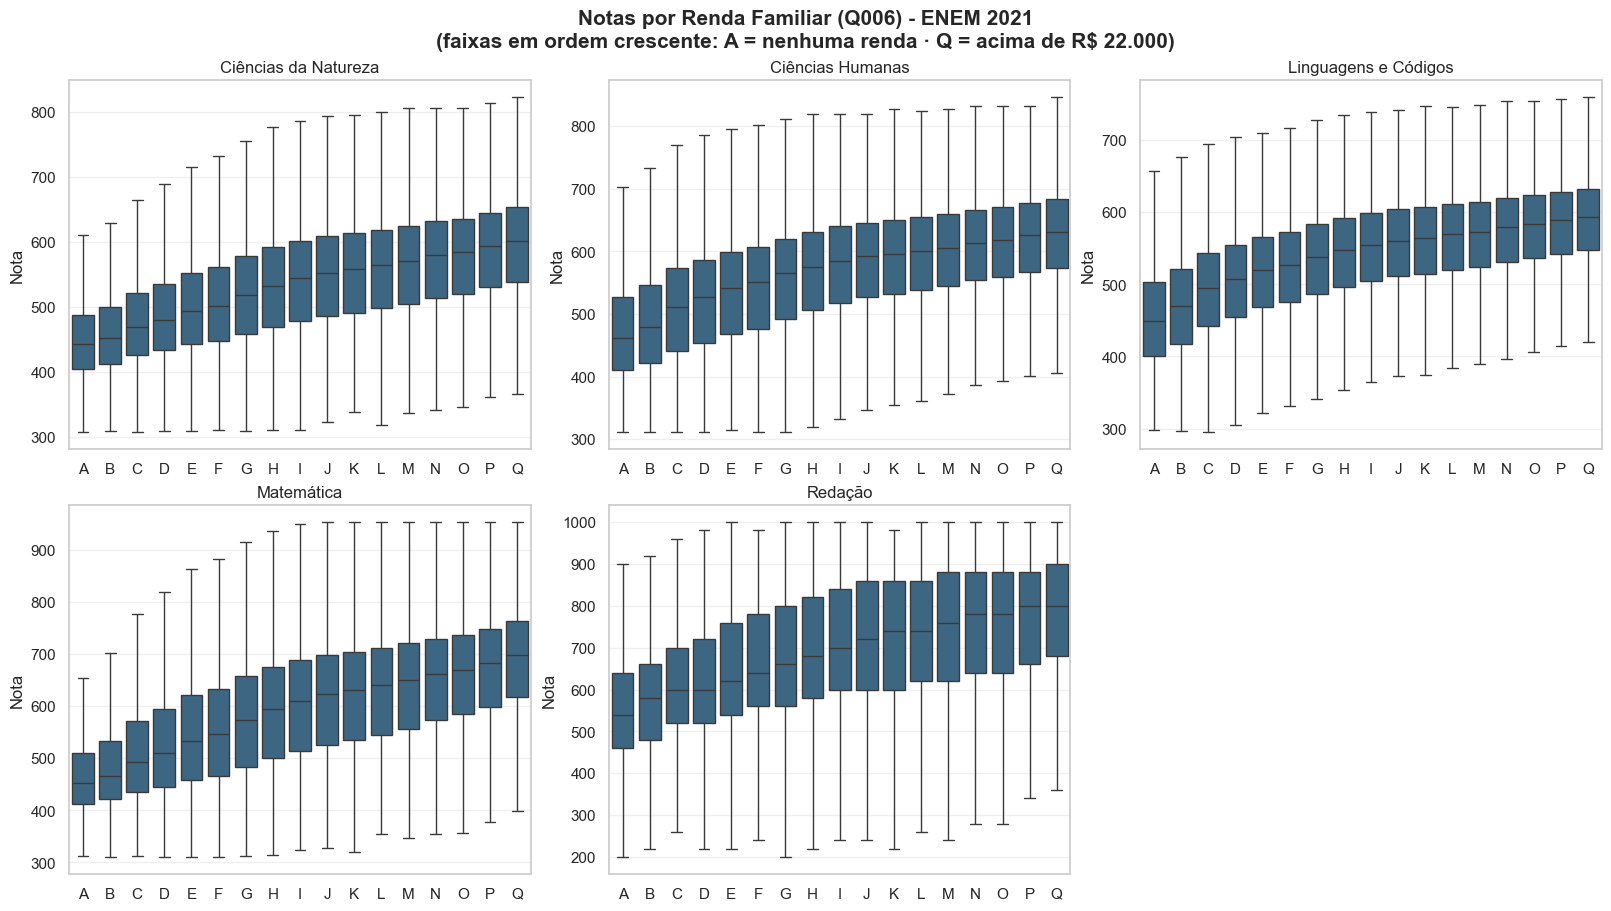

In [10]:
boxplots_por_grupo(
    df, 'Q6_Renda_Fam', ORDEM_Q6,
    f'Notas por Renda Familiar (Q006) - ENEM {ANO}\n'
    '(faixas em ordem crescente: A = nenhuma renda · Q = acima de R$ 22.000)',
    'fig_04_notas_por_renda')

Figura salva: ..\reports\figures\2021\fig_05_notas_por_escolaridade_mae.png


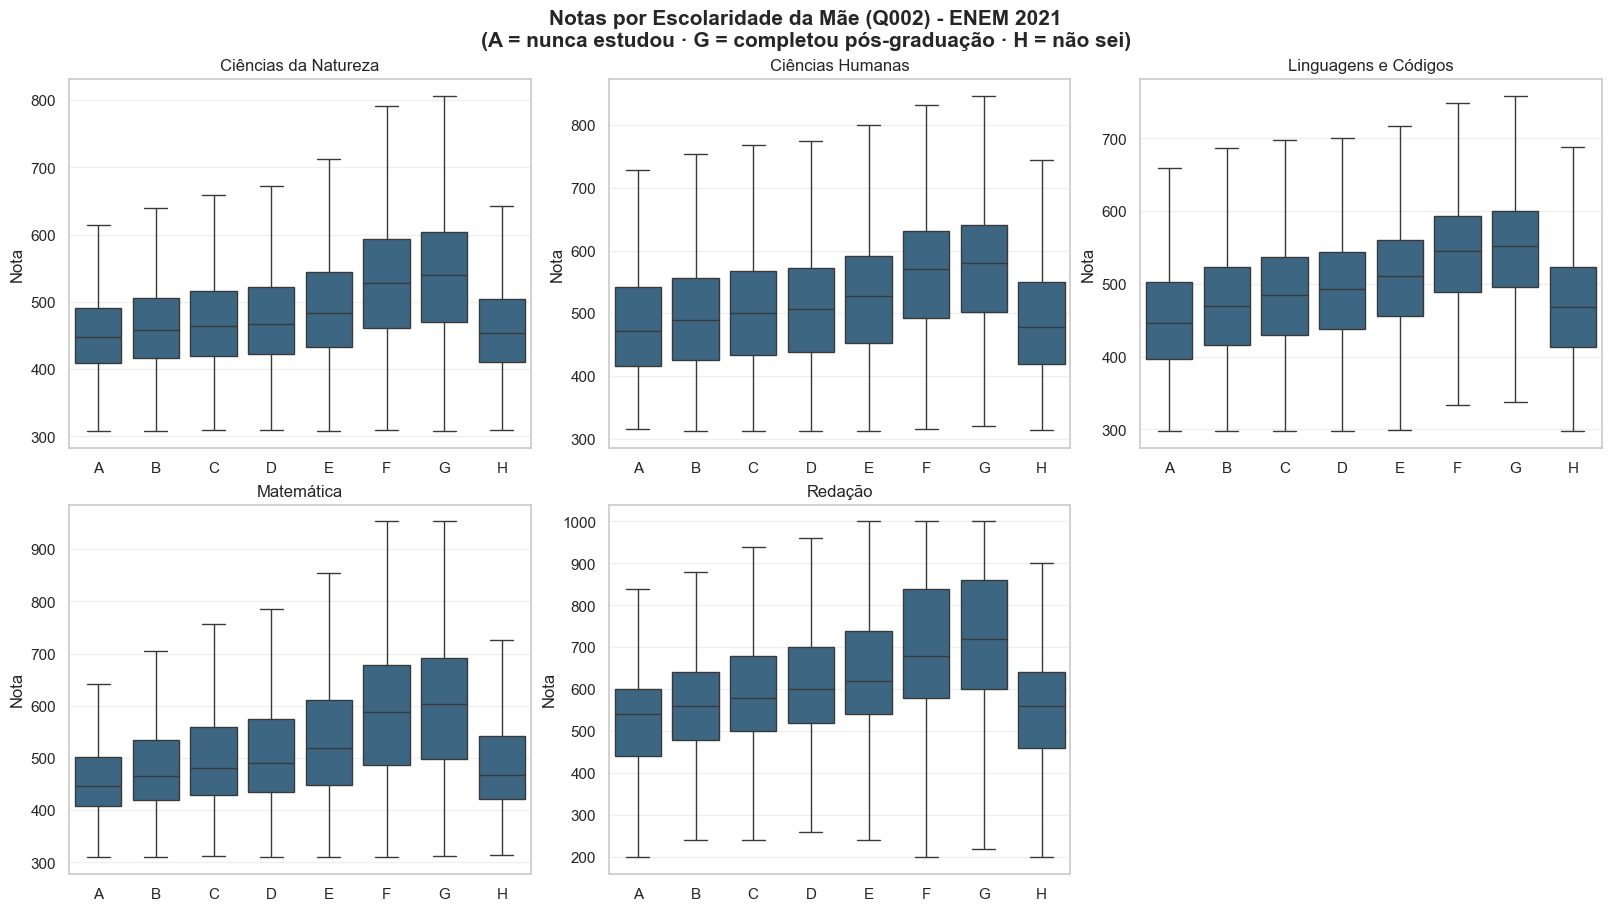

In [11]:
boxplots_por_grupo(
    df, 'Q2_Esc_Mae', ORDEM_Q2,
    f'Notas por Escolaridade da Mãe (Q002) - ENEM {ANO}\n'
    '(A = nunca estudou · G = completou pós-graduação · H = não sei)',
    'fig_05_notas_por_escolaridade_mae')

Figura salva: ..\reports\figures\2021\fig_06_notas_por_sexo.png


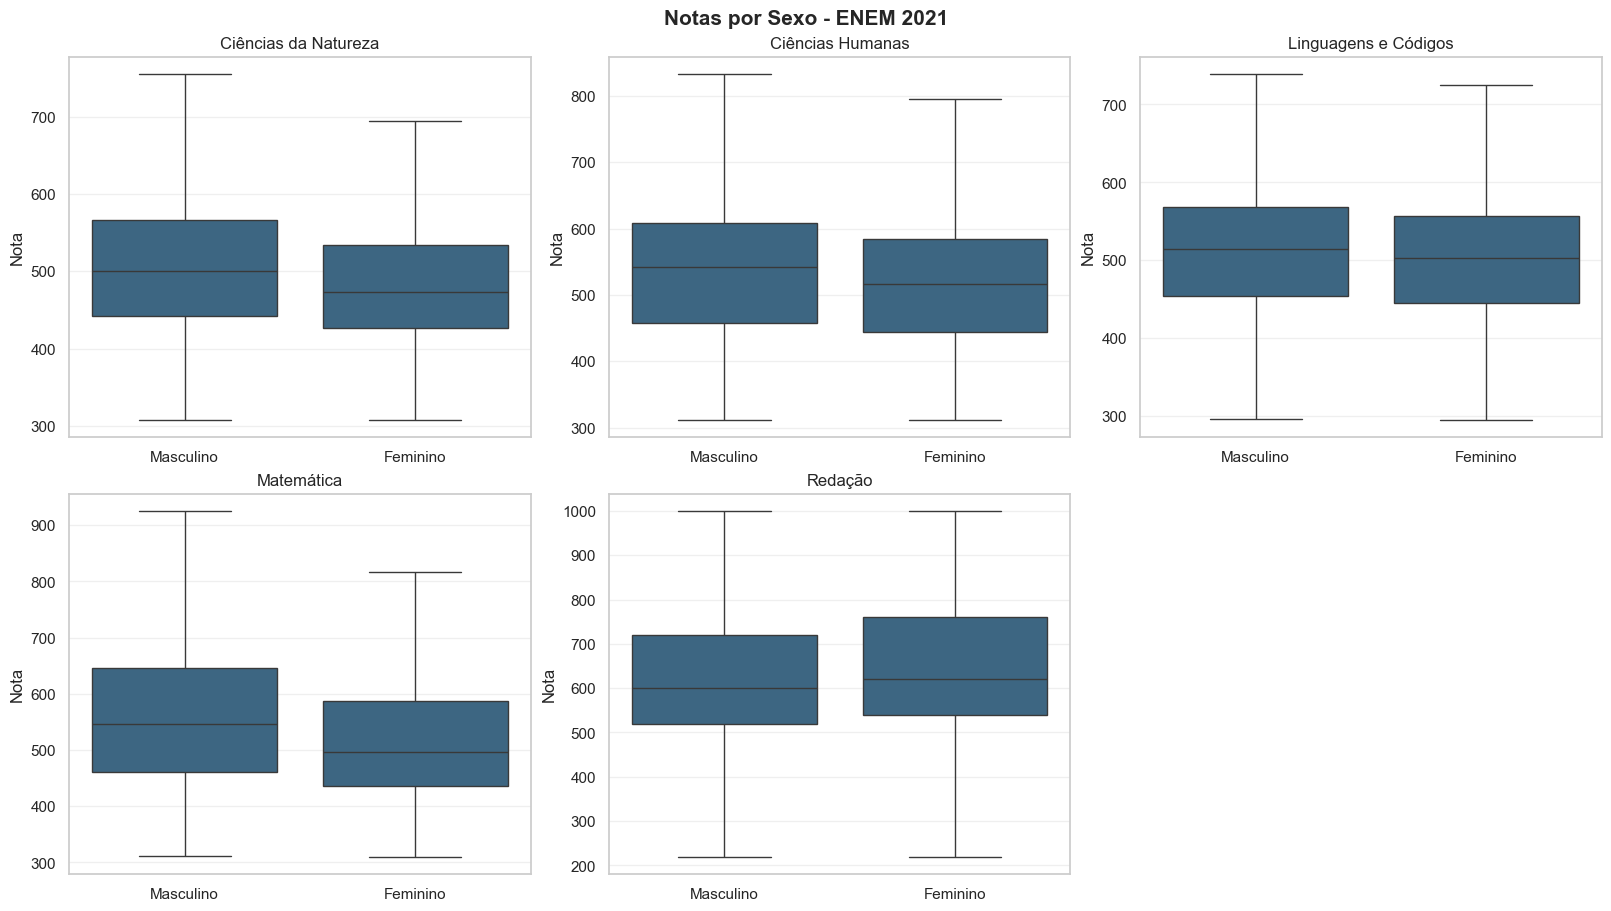

In [12]:
boxplots_por_grupo(df, 'Sexo_Label', ['Masculino', 'Feminino'],
                   f'Notas por Sexo - ENEM {ANO}',
                   'fig_06_notas_por_sexo')

Figura salva: ..\reports\figures\2021\fig_07_notas_por_computador_internet.png


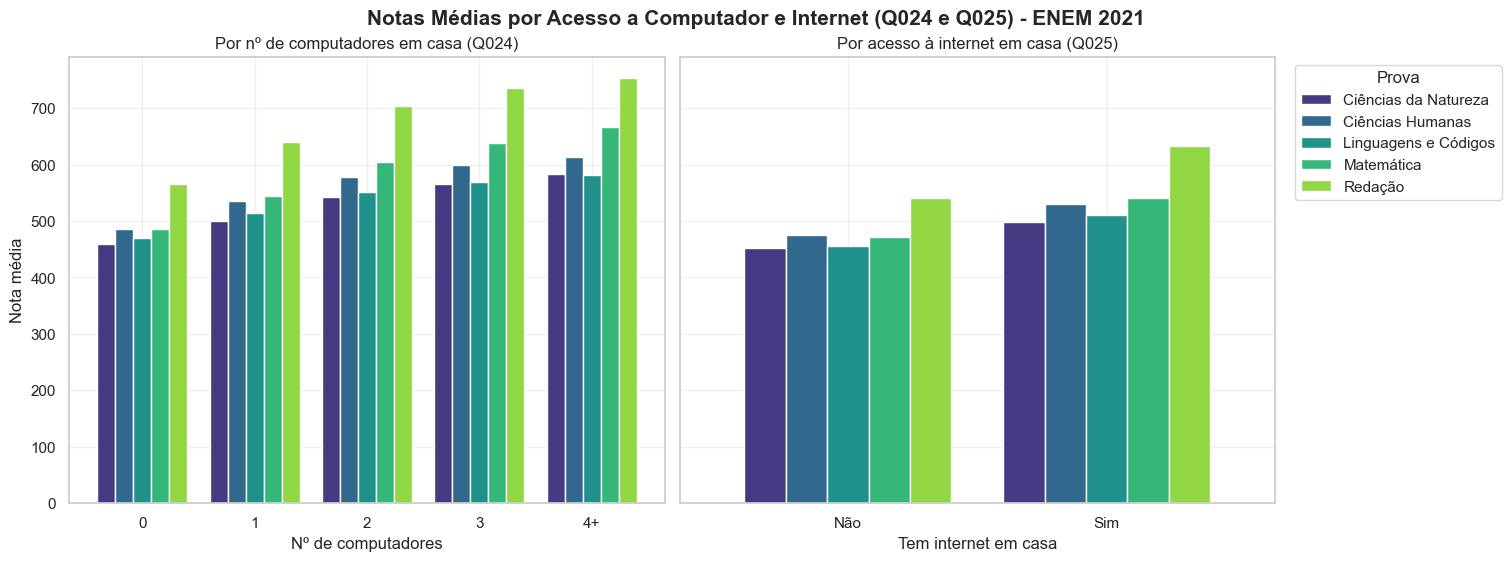

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)

medias_q24 = df.groupby(df['Q24_Computador'].map(MAPA_QTD))[NOTAS].mean().reindex(ORDEM_QTD)
medias_q24.columns = [NOMES_NOTAS[c] for c in medias_q24.columns]
medias_q24.plot(kind='bar', ax=axes[0], color=list(PALETA_NOTAS.values()),
                width=0.8, legend=False)
axes[0].set_title('Por nº de computadores em casa (Q024)')
axes[0].set_xlabel('Nº de computadores')
axes[0].set_ylabel('Nota média')
axes[0].tick_params(axis='x', rotation=0)

medias_q25 = df.groupby(df['Q25_Internet'].map(MAPA_Q25))[NOTAS].mean().reindex(['Não', 'Sim'])
medias_q25.columns = [NOMES_NOTAS[c] for c in medias_q25.columns]
medias_q25.plot(kind='bar', ax=axes[1], color=list(PALETA_NOTAS.values()), width=0.8)
axes[1].set_title('Por acesso à internet em casa (Q025)')
axes[1].set_xlabel('Tem internet em casa')
axes[1].legend(title='Prova', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle(f'Notas Médias por Acesso a Computador e Internet (Q024 e Q025) - ENEM {ANO}', fontsize=15, fontweight='bold')
salvar(fig, 'fig_07_notas_por_computador_internet')
plt.show()

## 4. Mapa - nota média geral por UF

O mapa coroplético é desenhado com matplotlib puro a partir do GeoJSON das UFs (`data/external/brazil_uf.geojson`). Caso o arquivo não exista, o código recorre a um gráfico de barras horizontais ordenado pelas médias.

Vale lembrar que `UF_Escola` só está preenchida para os candidatos com escola declarada; o mapa retrata, portanto, esse subconjunto.

Candidatos com UF da Escola Informada: 602,451
Figura salva: ..\reports\figures\2021\fig_08_mapa_media_geral_por_uf.png


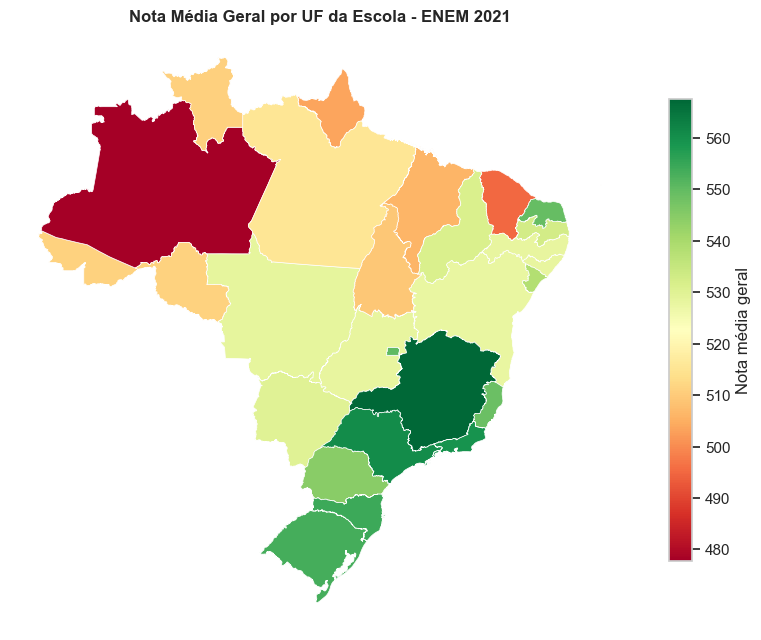

5 maiores médias por UF (da maior para a menor):
UF_Escola
MG    567.6
SP    560.6
RJ    559.3
SC    554.3
RS    553.3

5 menores médias por UF (da menor para a maior):
UF_Escola
AM    477.8
CE    495.2
AP    503.4
MA    506.1
TO    509.1


In [14]:
medias_uf = df.groupby('UF_Escola')['Nota_Media_Geral'].mean().dropna().sort_values()
print(f'Candidatos com UF da Escola Informada: {df["UF_Escola"].notna().sum():,}')

mapa_brasil = gpd.read_file(GEOJSON_PATH)
mapa_brasil['Media_Geral'] = mapa_brasil['sigla'].map(medias_uf)

fig, ax = plt.subplots(figsize=(10, 10))
mapa_brasil.plot(column='Media_Geral', cmap='RdYlGn', edgecolor='white', linewidth=0.5,
                 legend=True, legend_kwds={'label': 'Nota média geral', 'shrink': 0.6},
                 missing_kwds={'color': '#d9d9d9'}, ax=ax)
ax.axis('off')
ax.set_title(f'Nota Média Geral por UF da Escola - ENEM {ANO}', fontsize=12, fontweight='bold')
salvar(fig, 'fig_08_mapa_media_geral_por_uf')
plt.show()

print('5 maiores médias por UF (da maior para a menor):')
print(medias_uf.sort_values(ascending=False).head(5).astype(float).round(1).to_string())
print('\n5 menores médias por UF (da menor para a maior):')
print(medias_uf.head(5).astype(float).round(1).to_string())

## 5. Análise fragmentada - dando rosto aos dados

Aqui os números ganham concretude: comparamos a nota média geral entre grupos definidos pelo questionário socioeconômico - quem tem e quem não tem geladeira, computador ou banheiro em casa, faixas de renda e escolaridade da mãe.

Na comparação de banheiros, contrastamos quem não tem banheiro (`A`) com quem tem dois ou mais (`C`, `D`, `E`); pelo dicionário oficial, `A` indica ausência de banheiro, e não "um banheiro". Como referência para as faixas de renda, o salário mínimo de 2021 era R$ 1.100.

In [15]:
def media_e_n(filtro, nota='Nota_Media_Geral'):
    serie = df.loc[filtro, nota]
    return serie.mean(), len(serie)


def comparar(desc_a, filtro_a, desc_b, filtro_b):
    ma, na = media_e_n(filtro_a)
    mb, nb = media_e_n(filtro_b)
    print(f'Alunos {desc_a} tiraram em média {ma:.1f} pontos na média geral; '
          f'alunos {desc_b} tiraram {mb:.1f} - diferença de {abs(mb - ma):.1f} pontos. '
          f'(n = {na:,} vs {nb:,})\n')


# a) Geladeiras
comparar('sem geladeira em casa (Q012=A)',
         df['Q12_Geladeira'] == 'A',
         'com 2 ou mais geladeiras (Q012=C,D,E)',
         df['Q12_Geladeira'].isin(['C', 'D', 'E']))

# b) Computadores
comparar('sem computador em casa (Q024=A)',
         df['Q24_Computador'] == 'A',
         'com 2 ou mais computadores (Q024=C,D,E)',
         df['Q24_Computador'].isin(['C', 'D', 'E']))

# c) Banheiros (dicionário oficial: A = não tem banheiro)
comparar('sem banheiro em casa (Q008=A)',
         df['Q8_Banheiro'] == 'A',
         'com 2 ou mais banheiros (Q008=C,D,E)',
         df['Q8_Banheiro'].isin(['C', 'D', 'E']))

# d) Renda familiar (salário mínimo 2021 = R$ 1.100)
grupos_renda = [
    ('até 1 salário mínimo (Q006=A,B)', list('AB')),
    ('entre 1 e 5 salários mínimos (Q006=C-H)', list('CDEFGH')),
    ('entre 5 e 10 salários mínimos (Q006=I-M)', list('IJKLM')),
    ('mais de 10 salários mínimos (Q006=N-Q)', list('NOPQ')),
]
print('Renda familiar:')
medias_renda = []
for desc, letras in grupos_renda:
    m, n = media_e_n(df['Q6_Renda_Fam'].isin(letras))
    medias_renda.append(m)
    print(f'  Alunos com renda {desc}: média geral de {m:.1f} (n = {n:,})')
print(f'  → Diferença entre extremos: {medias_renda[-1] - medias_renda[0]:.1f} pontos.\n')

# e) Escolaridade da mãe
grupos_mae = [
    ('mãe que nunca estudou (Q002=A)', ['A']),
    ('mãe com ens. fundamental completo, sem ens. médio (Q002=D)', ['D']),
    ('mãe com ensino médio completo, sem faculdade (Q002=E)', ['E']),
    ('mãe com graduação ou pós (Q002=F,G)', ['F', 'G']),
]
print('Escolaridade da mãe:')
medias_mae = []
for desc, letras in grupos_mae:
    m, n = media_e_n(df['Q2_Esc_Mae'].isin(letras))
    medias_mae.append(m)
    print(f'  Alunos com {desc}: média geral de {m:.1f} (n = {n:,})')
print(f'  → Diferença entre extremos: {medias_mae[-1] - medias_mae[0]:.1f} pontos.')

Alunos sem geladeira em casa (Q012=A) tiraram em média 483.8 pontos na média geral; alunos com 2 ou mais geladeiras (Q012=C,D,E) tiraram 583.1 - diferença de 99.3 pontos. (n = 20,903 vs 97,845)

Alunos sem computador em casa (Q024=A) tiraram em média 493.0 pontos na média geral; alunos com 2 ou mais computadores (Q024=C,D,E) tiraram 607.2 - diferença de 114.2 pontos. (n = 738,181 vs 332,765)

Alunos sem banheiro em casa (Q008=A) tiraram em média 469.7 pontos na média geral; alunos com 2 ou mais banheiros (Q008=C,D,E) tiraram 575.9 - diferença de 106.2 pontos. (n = 10,752 vs 673,632)

Renda familiar:
  Alunos com renda até 1 salário mínimo (Q006=A,B): média geral de 491.1 (n = 587,909)
  Alunos com renda entre 1 e 5 salários mínimos (Q006=C-H): média geral de 541.0 (n = 1,016,926)
  Alunos com renda entre 5 e 10 salários mínimos (Q006=I-M): média geral de 605.8 (n = 175,801)
  Alunos com renda mais de 10 salários mínimos (Q006=N-Q): média geral de 640.4 (n = 90,097)
  → Diferença entre 

Figura salva: ..\reports\figures\2021\fig_09_fragmentacao_geladeiras.png


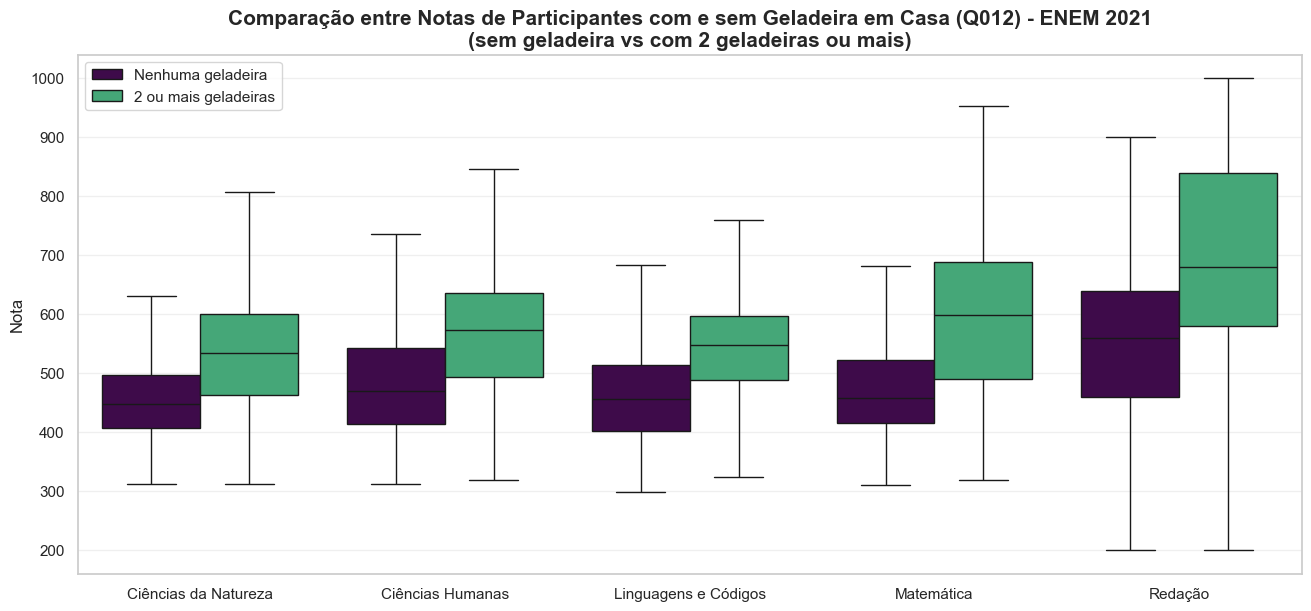

In [16]:
# Fragmentação: nenhuma geladeira vs 2 ou mais (Q012 C,D,E), mesmo recorte da comparação em texto
frag = pd.concat([
    df[df['Q12_Geladeira'] == 'A'].assign(Grupo='Nenhuma geladeira'),
    df[df['Q12_Geladeira'].isin(['C', 'D', 'E'])].assign(Grupo='2 ou mais geladeiras'),
])
longo = frag.melt(id_vars='Grupo', value_vars=NOTAS, var_name='Prova', value_name='Nota')
longo['Prova'] = longo['Prova'].map(NOMES_NOTAS)

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
sns.boxplot(data=longo, x='Prova', y='Nota', hue='Grupo',
            hue_order=['Nenhuma geladeira', '2 ou mais geladeiras'],
            palette=['#440154', '#35b779'], showfliers=False, ax=ax)
ax.set_title(f'Comparação entre Notas de Participantes com e sem Geladeira em Casa (Q012) - ENEM {ANO}\n'
             '(sem geladeira vs com 2 geladeiras ou mais)', fontsize=15, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nota')
ax.legend(title='')
salvar(fig, 'fig_09_fragmentacao_geladeiras')
plt.show()

## 6. Quais fatores têm maior relação com o desempenho? (Spearman)

Esta seção responde à pergunta de pesquisa: medimos a força da relação de cada fator socioeconômico com o desempenho pela correlação de Spearman e ordenamos os fatores pelo |ρ| com a média geral das cinco notas.

A escolha de Spearman, e não Pearson, se deve à natureza ordinal das questões do questionário: as respostas seguem uma ordem natural (A < B < C…), preservada na codificação (A=0, B=1, …). Categorias sem ordem, como "Não sei" e "Não declarado", viram `NaN` e ficam fora do cálculo.

Uma consequência dessa deleção par a par é que o **n varia de fator para fator**: renda familiar usa quase toda a base, enquanto tipo de escola usa apenas quem declarou escola pública ou privada - majoritariamente concluintes do ensino médio, já que "Não respondeu" é a categoria mais comum. Por transparência, a célula imprime o n de cada fator junto da tabela de correlações.

Cor/raça e dependência administrativa da escola não entram no ranking: são variáveis nominais com três ou mais categorias, e atribuir-lhes uma ordem numérica seria arbitrário, distorcendo a interpretação do ρ. Variáveis binárias, por outro lado, entram normalmente - com apenas duas categorias, a codificação 0/1 não impõe ordem falsa (o resultado equivale a uma correlação ponto-bisserial).

Codificações: tipo de escola (Pública=0, Privada=1) e sexo (M=0, F=1).

In [17]:
ESCALA = {letra: pos for pos, letra in enumerate('ABCDEFGHIJKLMNOPQ')}


def codificar_ordinal(serie, validas):
    """Letra -> posição ordinal; valores fora de `validas` (ex.: 'Não sei') viram NaN."""
    return serie.map({letra: ESCALA[letra] for letra in validas})


explicativas = pd.DataFrame({
    'Escolaridade do pai (Q1)': codificar_ordinal(df['Q1_Esc_Pai'], 'ABCDEFG'),    # H = Não sei
    'Escolaridade da mãe (Q2)': codificar_ordinal(df['Q2_Esc_Mae'], 'ABCDEFG'),    # H = Não sei
    'Ocupação do pai (Q3)': codificar_ordinal(df['Q3_Ocup_Pai'], 'ABCDE'),         # F = Não sei
    'Ocupação da mãe (Q4)': codificar_ordinal(df['Q4_Ocup_Mae'], 'ABCDE'),         # F = Não sei
    'Pessoas na residência (Q5)': pd.to_numeric(df['Q5_Pessoas_Resid'], errors='coerce'),
    'Renda familiar (Q6)': codificar_ordinal(df['Q6_Renda_Fam'], 'ABCDEFGHIJKLMNOPQ'),
    'Nº de banheiros (Q8)': codificar_ordinal(df['Q8_Banheiro'], 'ABCDE'),
    'Nº de geladeiras (Q12)': codificar_ordinal(df['Q12_Geladeira'], 'ABCDE'),
    'Nº de computadores (Q24)': codificar_ordinal(df['Q24_Computador'], 'ABCDE'),
    'Tem internet (Q25)': codificar_ordinal(df['Q25_Internet'], 'AB'),
    'Tipo de escola (Pública=0, Privada=1)': df['Tipo_Escola'].map({2: 0, 3: 1}),
    'Sexo (M=0, F=1)': df['Sexo'].map({'M': 0, 'F': 1}),
})

correlacoes = pd.DataFrame({
    NOMES_NOTAS[nota]: explicativas.corrwith(df[nota], method='spearman')
    for nota in ['Nota_Media_Geral'] + NOTAS
})

# Ranking que responde à pergunta de pesquisa: fatores ordenados pelo |ρ| com a média geral
correlacoes = correlacoes.loc[correlacoes['Média Geral'].abs().sort_values(ascending=False).index]

# Transparência: cada linha usa só os candidatos com o fator preenchido (deleção par a par)
print('n usado em cada correlação (candidatos com o fator preenchido):')
print(explicativas.notna().sum().reindex(correlacoes.index).map('{:,}'.format).to_string())

correlacoes.round(3)

n usado em cada correlação (candidatos com o fator preenchido):
Renda familiar (Q6)                      1,870,733
Nº de computadores (Q24)                 1,870,733
Tipo de escola (Pública=0, Privada=1)      847,397
Ocupação do pai (Q3)                     1,671,804
Escolaridade do pai (Q1)                 1,717,977
Ocupação da mãe (Q4)                     1,722,431
Escolaridade da mãe (Q2)                 1,827,318
Nº de banheiros (Q8)                     1,870,733
Tem internet (Q25)                       1,870,733
Nº de geladeiras (Q12)                   1,870,733
Sexo (M=0, F=1)                          1,870,734
Pessoas na residência (Q5)               1,870,733


,Média Geral,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação
Renda familiar (Q6),0.465,0.402,0.390,0.422,0.433,0.329
Nº de computadores (Q24),0.450,0.393,0.388,0.411,0.403,0.318
"Tipo de escola (Pública=0, Privada=1)",0.401,0.338,0.306,0.326,0.349,0.352
Ocupação do pai (Q3),0.387,0.322,0.316,0.364,0.354,0.287
Escolaridade do pai (Q1),0.370,0.302,0.287,0.339,0.342,0.287
Ocupação da mãe (Q4),0.367,0.304,0.294,0.341,0.335,0.279
Escolaridade da mãe (Q2),0.356,0.287,0.264,0.318,0.329,0.289
Nº de banheiros (Q8),0.345,0.298,0.276,0.302,0.322,0.266
Tem internet (Q25),0.208,0.163,0.169,0.198,0.184,0.151
Nº de geladeiras (Q12),0.130,0.115,0.105,0.117,0.127,0.093


Figura salva: ..\reports\figures\2021\fig_10_heatmap_correlacoes.png


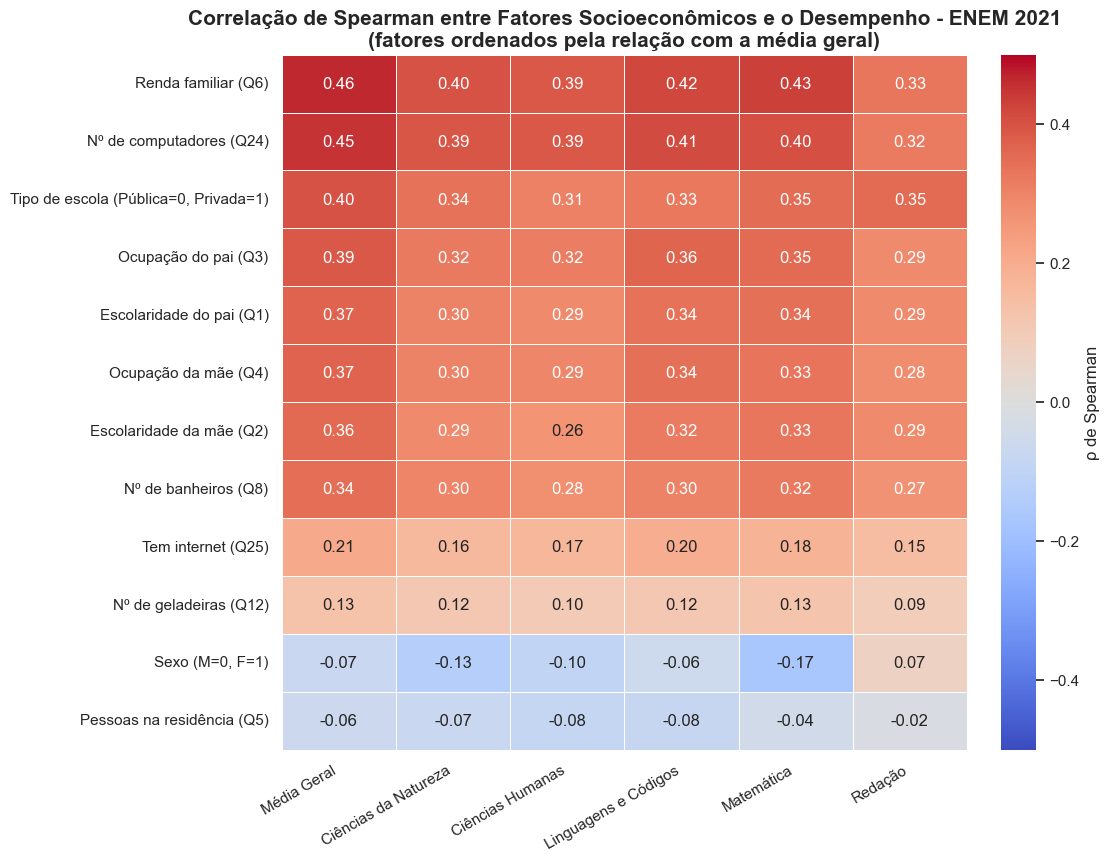

In [18]:
fig, ax = plt.subplots(figsize=(11, 8.5), constrained_layout=True)
sns.heatmap(correlacoes, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'ρ de Spearman'}, ax=ax)
ax.set_title(f'Correlação de Spearman entre Fatores Socioeconômicos e o Desempenho - ENEM {ANO}\n'
             f'(fatores ordenados pela relação com a média geral)', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
salvar(fig, 'fig_10_heatmap_correlacoes')
plt.show()

Figura salva: ..\reports\figures\2021\fig_11_ranking_fatores_media_geral.png


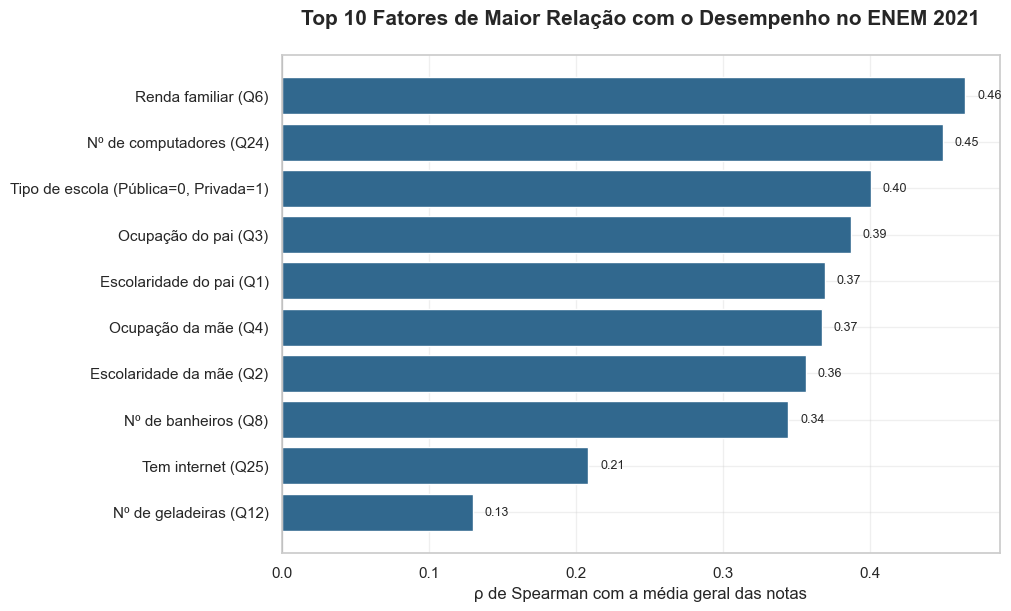

In [19]:
# Resposta à pergunta de pesquisa: fatores com maior |ρ| com a média geral das 5 notas
rank_geral = correlacoes['Média Geral'].abs().sort_values(ascending=False).head(10)
valores = correlacoes.loc[rank_geral.index, 'Média Geral'].iloc[::-1]  # invertido p/ barh

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.barh(valores.index, valores.values, color=COR_UNICA)
for i, v in enumerate(valores.values):
    ax.text(v + (0.008 if v >= 0 else -0.008), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title(f'Top 10 Fatores de Maior Relação com o Desempenho no ENEM {ANO}\n', fontsize=15, fontweight='bold')
ax.set_xlabel('ρ de Spearman com a média geral das notas')
salvar(fig, 'fig_11_ranking_fatores_media_geral')
plt.show()

## 7. Achados de 2021

A célula a seguir calcula e imprime os números-chave deste ano a partir dos dados já processados nas seções anteriores. A síntese comparando todos os anos está em `analise_consolidada_edicoes_enem.ipynb`.

In [20]:
top3 = correlacoes['Média Geral'].abs().sort_values(ascending=False).head(3)
print('- Fatores de maior relação com o desempenho: '
      + '; '.join(f'{fator} (ρ = {correlacoes.loc[fator, "Média Geral"]:.2f})'
                  for fator in top3.index) + '.')

geral_pub = df.loc[df['Tipo_Escola'] == 2, 'Nota_Media_Geral'].mean()
geral_priv = df.loc[df['Tipo_Escola'] == 3, 'Nota_Media_Geral'].mean()
print(f'- Média geral, escola pública vs privada: {geral_pub:.1f} vs {geral_priv:.1f} '
      f'- diferença de {geral_priv - geral_pub:.1f} pontos '
      f'({(geral_priv / geral_pub - 1) * 100:.0f}% a mais na privada).')

renda_baixa = df.loc[df['Q6_Renda_Fam'].isin(['A', 'B']), 'Nota_Media_Geral'].mean()
renda_alta = df.loc[df['Q6_Renda_Fam'].isin(['N', 'O', 'P', 'Q']), 'Nota_Media_Geral'].mean()
print(f'- Renda até 1 salário mínimo vs mais de 10 salários mínimos: {renda_baixa:.1f} vs {renda_alta:.1f} '
      f'- diferença de {renda_alta - renda_baixa:.1f} pontos.')

mae_a = df.loc[df['Q2_Esc_Mae'] == 'A', 'Nota_Media_Geral'].mean()
mae_fg = df.loc[df['Q2_Esc_Mae'].isin(['F', 'G']), 'Nota_Media_Geral'].mean()
print(f'- Mãe que nunca estudou vs mãe com graduação/pós: '
      f'{mae_a:.1f} vs {mae_fg:.1f} - diferença de {mae_fg - mae_a:.1f} pontos.')

net_nao = df.loc[df['Q25_Internet'] == 'A', 'Nota_Media_Geral'].mean()
net_sim = df.loc[df['Q25_Internet'] == 'B', 'Nota_Media_Geral'].mean()
print(f'- Sem internet vs com internet em casa: {net_nao:.1f} vs {net_sim:.1f} '
      f'- diferença de {net_sim - net_nao:.1f} pontos.')

gel_0 = df.loc[df['Q12_Geladeira'] == 'A', 'Nota_Media_Geral'].mean()
gel_2 = df.loc[df['Q12_Geladeira'].isin(['C', 'D', 'E']), 'Nota_Media_Geral'].mean()
print(f'- Sem geladeira vs 2+ geladeiras: {gel_0:.1f} vs {gel_2:.1f} '
      f'- diferença de {gel_2 - gel_0:.1f} pontos.')

uf_top = medias_uf.idxmax()
uf_bottom = medias_uf.idxmin()
print(f'- UF com maior média geral: {uf_top} ({medias_uf.max():.1f}); '
      f'menor: {uf_bottom} ({medias_uf.min():.1f}) '
      f'- diferença de {medias_uf.max() - medias_uf.min():.1f} pontos.')

- Fatores de maior relação com o desempenho: Renda familiar (Q6) (ρ = 0.46); Nº de computadores (Q24) (ρ = 0.45); Tipo de escola (Pública=0, Privada=1) (ρ = 0.40).
- Média geral, escola pública vs privada: 509.0 vs 598.8 - diferença de 89.8 pontos (18% a mais na privada).
- Renda até 1 salário mínimo vs mais de 10 salários mínimos: 491.1 vs 640.4 - diferença de 149.3 pontos.
- Mãe que nunca estudou vs mãe com graduação/pós: 473.0 vs 586.3 - diferença de 113.3 pontos.
- Sem internet vs com internet em casa: 479.0 vs 542.1 - diferença de 63.0 pontos.
- Sem geladeira vs 2+ geladeiras: 483.8 vs 583.1 - diferença de 99.3 pontos.
- UF com maior média geral: MG (567.6); menor: AM (477.8) - diferença de 89.8 pontos.
